In [32]:
# autoreload
%load_ext autoreload
%autoreload 2

#from scipy import signal
#from scipy import interpolate
#from scipy import ndimage
import numpy as np
#import pycatch22 
#from sktime.transformations.panel import catch22
#import tsfresh
from tqdm import tqdm
import sys, os
import pandas as pd 
import dotenv
load_dotenv = dotenv.load_dotenv('../.env')
# load local library
sys.path.append(os.path.join(os.getcwd(), '..', 'src'))
import extractor
import preprocessing
#import wavelets

import gc
import seaborn as sns
import matplotlib.pyplot as plt

from collections import defaultdict

#from time import sleep

#from scipy.stats import skew, kurtosis
#from scipy.fft import rfft, rfftfreq
#from scipy.signal import cwt, ricker
#import pymannkendall as mk

# explicitly require this experimental feature
from sklearn.experimental import enable_iterative_imputer  # noqa
# now you can import normally from sklearn.impute
#from sklearn.impute import IterativeImputer
#from sklearn.impute import SimpleImputer, KNNImputer
#from sklearn.preprocessing import StandardScaler, QuantileTransformer
#from sklearn.decomposition import PCA
#from sklearn.cluster import KMeans, AffinityPropagation, SpectralClustering, HDBSCAN
#from sklearn.mixture import GaussianMixture as GMM
#from umap import UMAP
#from scaler import GaussRankScaler
#from sklearn.pipeline import Pipeline
#import nolds

import datetime

#from numba import jit
#from typing import Union, List, Literal, Generator, Tuple


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [33]:
START_TIME = datetime.datetime.now()

In [34]:
AKI_PATH = os.environ['AKI_PATH']
os.chdir(AKI_PATH)

In [35]:
AKI_PATH

'L:\\\\lab_research\\\\RES-Folder-UPOD\\\\Nostradamus/E_ResearchData/2_ResearchData/Prd_RenalFunc'

In [36]:
# load pre-selection
ts_data = pd.read_parquet("./Bram_v2/test_data.parquet")
ts_data = ts_data.assign(ID=ts_data.ID.astype('int64'))

d = pd.to_datetime(ts_data.lab_date).dt.date - pd.to_datetime(ts_data.Start_AKI_episode_1).dt.date
ts_data['Time_days'] = d.apply(lambda x: x.days)

In [37]:
ts_data = ts_data[['ID', 'eGFRcr_CKDEpi2009', 'Time_days']]

## Exploration

In [38]:
min_days_length = 1*365
maxts = ts_data.groupby('ID').Time_days.max()
ltids = maxts[maxts>min_days_length].index

print(f'There are {ltids.shape[0]} patients (or {round(100*ltids.shape[0]/maxts.shape[0], 2)}%) with minimally {min_days_length} days of measurements')

There are 4091 patients (or 74.83%) with minimally 365 days of measurements


## Aggregregate per min time unit (a day in this case)

In [39]:
ts_data = ts_data.groupby(['ID', 'Time_days']).eGFRcr_CKDEpi2009.mean().reset_index()

## Preprocess

In [40]:
# TODONE: SOLVED with Nskip parameter in smoothing functions; make sure the first measurement is not affect by smoothing
# TODONE: just group by; check time resolution unit -> might be multiple measurement per minimum timeunit (e.g. multiple measurements per day)
# TODONE: add option to get_filtered_df to select based on closedness to first AKI

# TODO: concatenate both True/False for standardisation

In [125]:
RangeList = [3650] #+ list(np.arange(1*365,10*365, 365))
WINDOW_SIZE = 14 # for smoothing
MIN_MEASUREMENTS_PER_YEAR = 3
SMOOTHING_TYPE = 'rolling_mean' #'gaussian_kernel' # rolling_mean or gaussian_kernel
#STANDARDIZE_TS = True 
STANDARDIZE_TYPE = 'minmax'
TIME_RESOLUTION = 1 # days, for interpolation.
CLUSTER_NUM_LIST = [4,10,16]
NUM_BEFORE_FIRST_AKI = 1 # NBFA
NUM_SKIP = 3 # NS

In [126]:
ts_data['time_rank'] = ts_data.sort_values(by=['ID', 'Time_days'])\
                              .groupby('ID').Time_days.rank()
tmp = ts_data.loc[ts_data.Time_days==0][['ID','time_rank']]\
            .rename(columns={'time_rank': 'time_rank_zero'})
ts_data = ts_data.merge(tmp, on='ID', how='left')
ts_data = ts_data.loc[ts_data[['time_rank', 'time_rank_zero']]\
                      .apply(lambda x: (x[0]-x[1])>=-NUM_BEFORE_FIRST_AKI, axis=1),
                      ['ID', 'Time_days', 'eGFRcr_CKDEpi2009']]

RangeDFDict = {'raw': defaultdict(pd.DataFrame), 
                'normalised': defaultdict(pd.DataFrame)}
RangeDFDict_smoothed = {'raw': defaultdict(pd.DataFrame), 
                        'normalised': defaultdict(pd.DataFrame)}

for MinDays in RangeList:    
    MIN_MEASUREMENTS = np.floor(MIN_MEASUREMENTS_PER_YEAR*MinDays/365)
    
    print(f'Filtering for min days: {MinDays}')
    ts_temp = preprocessing.get_filtered_df(ts_data.copy(), 
                                            id_col='ID', 
                                            time_col='Time_days',
                                            min_days=MinDays, 
                                            min_measurements=MIN_MEASUREMENTS)    
    
    remaining_ids = ts_temp.ID.unique()
    print(f'Interpolating for min days: {MinDays}')
    RangeDFDict['raw'][MinDays] = preprocessing.get_interpolated(ts_temp, id_col='ID', 
                                                          time_col='Time_days',
                                                          max_days=MinDays,
                                                          days_before=NUM_BEFORE_FIRST_AKI,
                                                          val_col='eGFRcr_CKDEpi2009',
                                                          time_res=TIME_RESOLUTION,
                                                          df_out=True)
    
    print(f"Smoothing for min days: {MinDays} with window {WINDOW_SIZE}")
    if SMOOTHING_TYPE == 'rolling_mean':
        RangeDFDict_smoothed['raw'][MinDays] = preprocessing.get_smoothed_rolling_mean(RangeDFDict['raw'][MinDays].copy(),
                                                        id_col='ID',
                                                        time_col='Time_days',
                                                        val_col='eGFRcr_CKDEpi2009', 
                                                        window=WINDOW_SIZE,
                                                        Nskip=NUM_SKIP, 
                                                        df_out=True)
    elif SMOOTHING_TYPE == 'gaussian_kernel':
        RangeDFDict_smoothed['raw'][MinDays] = preprocessing.get_smoothed_gaussian_kernel(RangeDFDict['raw'][MinDays].copy(),
                                                        id_col='ID', 
                                                        time_col='Time_days',
                                                        val_col='eGFRcr_CKDEpi2009', 
                                                        window=WINDOW_SIZE,
                                                        Nskip=NUM_SKIP,
                                                        df_out=True)

    print(f'Standardizing for min days: {MinDays}')
    RangeDFDict['normalised'][MinDays] = preprocessing.normalise_ts(
                                         RangeDFDict['raw'][MinDays], 
                                         id_col='ID', 
                                         time_col='Time_days',
                                         val_col='eGFRcr_CKDEpi2009',
                                         df_out=True,
                                         scaler=STANDARDIZE_TYPE)
    
    RangeDFDict_smoothed['normalised'][MinDays] = preprocessing.normalise_ts(
                                         RangeDFDict_smoothed['raw'][MinDays], 
                                         id_col='ID', 
                                         time_col='Time_days',
                                         val_col='eGFRcr_CKDEpi2009',
                                         df_out=True,
                                         scaler=STANDARDIZE_TYPE)
    

Filtering for min days: 3650
Interpolating for min days: 3650


100%|██████████| 1517/1517 [00:04<00:00, 334.88it/s]


Smoothing for min days: 3650 with window 14


100%|██████████| 1517/1517 [00:14<00:00, 101.62it/s]


Standardizing for min days: 3650


100%|██████████| 1517/1517 [00:19<00:00, 77.72it/s] 


26768865387


Text(0.5, 0, 'Time in days')

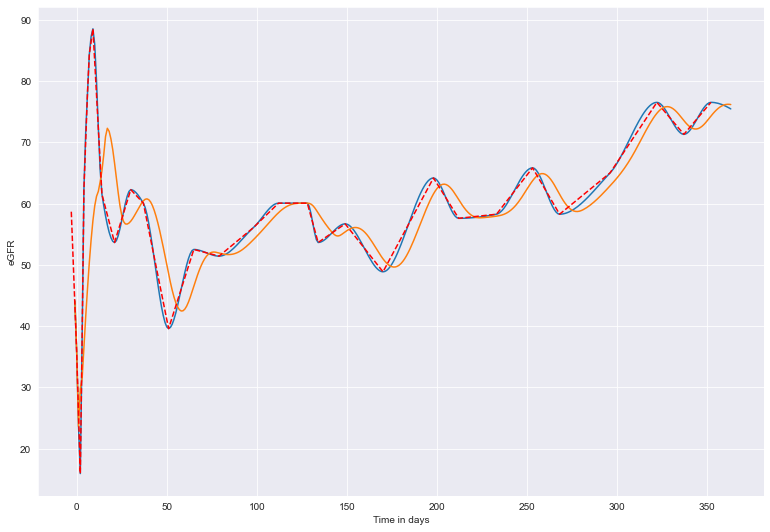

In [130]:
# Write prepped TS to disk
Range = 365
IDSEL = 413 # 31974771
_ID = remaining_ids[IDSEL]
print(_ID)

x_or = ts_data.query(f'ID=={_ID} & Time_days<={Range}')['Time_days']
y_or = ts_data.query(f'ID=={_ID} & Time_days<={Range}')['eGFRcr_CKDEpi2009']

x = RangeDFDict['raw'][3650].query(f'ID=={_ID}')['Time_days']
y = RangeDFDict['raw'][3650].query(f'ID=={_ID}')['eGFRcr_CKDEpi2009']

xs = RangeDFDict_smoothed['raw'][3650].query(f'ID=={_ID}')['Time_days']
ys = RangeDFDict_smoothed['raw'][3650].query(f'ID=={_ID}')['eGFRcr_CKDEpi2009']

plt.figure(figsize=(13,9))
plt.plot(x[:Range], y[:Range])
plt.plot(xs[:Range], ys[:Range])
plt.plot(x_or[:Range], y_or[:Range], color='red', linestyle='--')
plt.ylabel("eGFR")
plt.xlabel("Time in days")

In [128]:
# Write prepared timeseries to file
for k, v in RangeDFDict_smoothed.items():
    for _k, _v in v.items():
        _v.to_parquet(f"ts_smoothed_{k}_ST{SMOOTHING_TYPE}_{_k}_NS{NUM_SKIP}_NBFA{NUM_BEFORE_FIRST_AKI}_SW{WINDOW_SIZE}_ST{STANDARDIZE_TYPE}.parquet")
        
for k, v in RangeDFDict.items():
    for _k, _v in v.items():
        _v.to_parquet(f"ts_raw_{k}_{_k}_NS{NUM_SKIP}_NBFA{NUM_BEFORE_FIRST_AKI}_SW{WINDOW_SIZE}_ST{STANDARDIZE_TYPE}.parquet")

In [136]:
CrossSectDict = {}
# get_smoothNsmooth_diffStatistics
for MinDays in RangeList:
    print(f'RAW: Getting cross-sectional features for min days, for the smoothed set, with periods of: {MinDays} days')
    tsS = RangeDFDict_smoothed['raw'][MinDays]
    smoothed_cross_nonnorm = extractor.get_crossectional(tsS, 
                                        id_col='ID',
                                        val_col='eGFRcr_CKDEpi2009',
                                        time_col='Time_days',
                                        tsfresh_features=False,
                                        catch22_features=True,
                                        cesium_features=False,
                                        antropy_features=False,
                                        nolds_features=False)
    ############
    print(f'RAW: Getting cross-sectional features for min days, for the raw set, with periods of: {MinDays} days')
    tsR = RangeDFDict['raw'][MinDays]
    raw_cross_nonnorm = extractor.get_crossectional(tsR, 
                                        id_col='ID',
                                        val_col='eGFRcr_CKDEpi2009',
                                        time_col='Time_days',
                                        tsfresh_features=False,
                                        catch22_features=True,
                                        cesium_features=False,
                                        antropy_features=False,
                                        nolds_features=False)
    ############
    print(f'RAW: Merging cross-sectional features for min days, the raw set, with periods of: {MinDays} days')
    merged_cross_nonnorm = smoothed_cross_nonnorm.merge(raw_cross_nonnorm,
                                        left_index=True, 
                                        right_index=True, 
                                        suffixes=('_smoothed', '_raw'))
    smoothNsmoothStats = extractor.get_smoothNsmooth_diffStatistics(tsS,tsR, 
                                                                    id_col='ID',
                                                                    val_col='eGFRcr_CKDEpi2009',
                                                                    time_col='Time_days')
    
    smoothed_cross_nonnorm = smoothed_cross_nonnorm.merge(smoothNsmoothStats, left_index=True, right_index=True)
    raw_cross_nonnorm = raw_cross_nonnorm.merge(smoothNsmoothStats, left_index=True, right_index=True)
    merged_cross_nonnorm = merged_cross_nonnorm.merge(smoothNsmoothStats, left_index=True, right_index=True)
    
    smoothed_cross_nonnorm.columns = [f"{c}_NONNORM" for c in smoothed_cross_nonnorm.columns]
    raw_cross_nonnorm.columns = [f"{c}_NONNORM" for c in raw_cross_nonnorm.columns]
    merged_cross_nonnorm.columns = [f"{c}_NONNORM" for c in merged_cross_nonnorm.columns]
        
    #|||||||||||||||||||||||||||||
    #|||||||||||||||||||||||||||||
    
    print(f'NORMALISED: Getting cross-sectional features for min days, for the smoothed set, with periods of: {MinDays} days')
    tsS = RangeDFDict_smoothed['normalised'][MinDays]
    smoothed_cross_norm = extractor.get_crossectional(tsS, 
                                        id_col='ID',
                                        val_col='eGFRcr_CKDEpi2009',
                                        time_col='Time_days',
                                        tsfresh_features=False,
                                        catch22_features=True,
                                        cesium_features=False,
                                        antropy_features=False,
                                        nolds_features=False)
    ############
    print(f'NORMALISED: Getting cross-sectional features for min days, for the raw set, with periods of: {MinDays} days')
    tsR = RangeDFDict['normalised'][MinDays]
    raw_cross_norm = extractor.get_crossectional(tsR, 
                                        id_col='ID',
                                        val_col='eGFRcr_CKDEpi2009',
                                        time_col='Time_days',
                                        tsfresh_features=False,
                                        catch22_features=True,
                                        cesium_features=False,
                                        antropy_features=False,
                                        nolds_features=False)
    ############
    print(f'NORMALISED: Merging cross-sectional features for min days, the raw set, with periods of: {MinDays} days')
    merged_cross_norm = smoothed_cross_norm.merge(raw_cross_norm,
                                        left_index=True, 
                                        right_index=True, 
                                        suffixes=('_smoothed', '_raw'))
    smoothNsmoothStats = extractor.get_smoothNsmooth_diffStatistics(tsS,tsR, 
                                                                    id_col='ID',
                                                                    val_col='eGFRcr_CKDEpi2009',
                                                                    time_col='Time_days')
    
    smoothed_cross_norm = smoothed_cross_norm.merge(smoothNsmoothStats, left_index=True, right_index=True)
    raw_cross_norm = raw_cross_norm.merge(smoothNsmoothStats, left_index=True, right_index=True)
    merged_cross_norm = merged_cross_norm.merge(smoothNsmoothStats, left_index=True, right_index=True)
  
    smoothed_cross_norm.columns = [f"{c}_NORM" for c in smoothed_cross_norm.columns]
    raw_cross_norm.columns = [f"{c}_NORM" for c in raw_cross_norm.columns]
    merged_cross_norm.columns = [f"{c}_NORM" for c in merged_cross_norm.columns]
    
    # TODO: merge normalised and non_normalised
      
    smoothed_cross = smoothed_cross_norm.join(smoothed_cross_nonnorm, how='inner')
    raw_cross = raw_cross_norm.join(raw_cross_nonnorm, how='inner')
    merged_cross = merged_cross_norm.join(merged_cross_nonnorm, how='inner')
    
    CrossSectDict[MinDays] = {
                              'smoothed': smoothed_cross,
                              'raw': raw_cross,
                              'merged': merged_cross
                            }
    
    gc.collect()

RAW: Getting cross-sectional features for min days, for the smoothed set, with periods of: 3650 days


  1%|          | 12/1517 [02:31<5:16:01, 12.60s/it]


IndexError: tuple index out of range

## Remove redundant features

In [ ]:
# remove features that have more than N% of missing values
MAX_MISSING_VALUES_PER_COLUMN = 0.5

print("Removing features for all periods that are too sparse")
num_rem = []
for period in tqdm(CrossSectDict.keys()):
    for key in CrossSectDict[period].keys():
        FINAL_FEATURES = CrossSectDict[period][key]
        missing_ratio = FINAL_FEATURES.isna().sum(axis=0)/\
                            FINAL_FEATURES.shape[0]
        missing_cols = missing_ratio[missing_ratio>MAX_MISSING_VALUES_PER_COLUMN].index
        
        CrossSectDict[period][key] = FINAL_FEATURES.drop(columns=missing_cols)
        num_rem.append(missing_cols.shape[0])
        
print(f"Number of columns removed: {num_rem}")

In [ ]:
# remove plus or minus infinity values
print("Removing infinite values")
num_rem = []
for period in tqdm(CrossSectDict.keys()):
    for key in CrossSectDict[period].keys():
        FINAL_FEATURES = CrossSectDict[period][key]
        inf_cols = FINAL_FEATURES.columns[FINAL_FEATURES.isin([np.inf, -np.inf]).any()]
        CrossSectDict[period][key] = FINAL_FEATURES.drop(columns=inf_cols)
        num_rem.append(inf_cols.shape[0])

In [ ]:
from sklearn.feature_selection import VarianceThreshold

print("Removing zero variance features for all periods...")
num_zero = []
for period in tqdm(CrossSectDict.keys()):
    for key in CrossSectDict[period].keys():
        FINAL_FEATURES = CrossSectDict[period][key]
        
        var_thresh = VarianceThreshold(threshold=0.)
        var_thresh.fit(FINAL_FEATURES)
        variances = var_thresh.variances_

        # remove features with zero variance
        zero_variance_features = FINAL_FEATURES.columns[variances == 0]
        non_zero_variance_features = FINAL_FEATURES.columns[variances > 0]
        FINAL_FEATURES = FINAL_FEATURES.drop(zero_variance_features, axis=1)
        
        CrossSectDict[period][key] = FINAL_FEATURES
        num_zero.append(zero_variance_features.shape[0])  
        
print(f"Number of columns removed: {num_zero}")

In [ ]:
# remove features that are highly correlated
print("Removing perfectly correlated features for all periods...")
num_corr = []
duplicated = set()
for period in tqdm(CrossSectDict.keys()):
    for key in CrossSectDict[period].keys():
        FINAL_FEATURES = CrossSectDict[period][key]
        
        #dist_matrix = 1-FINAL_FEATURES.corr(method='spearman').abs()
        #cols = dist_matrix.columns        
        cols = FINAL_FEATURES.columns
        droplist = []
        for i,cl in enumerate(cols):
            for cr in cols[i+1:]:
                if FINAL_FEATURES[cl].equals(FINAL_FEATURES[cr]):
                    droplist.append(cr)
                    duplicated.add((cl, cr))
        to_drop = list(set(droplist))
                
        FINAL_FEATURES = FINAL_FEATURES.drop(columns=to_drop)
        CrossSectDict[period][key] = FINAL_FEATURES
        num_corr.append(len(to_drop))
print(f"Number of columns removed: {num_corr}")

In [ ]:
print(f"Duplicate column-pairs: {duplicated}")


## Imputation

In [ ]:
pipe_kwargs = {}

In [ ]:
#imputer = SimpleImputer(strategy='mean')
imputer = KNNImputer
pipe_kwargs['imputer'] = {'default': {'n_neighbors' :7, 'weights': 'distance'}
                          }

## Scale

In [ ]:
#scaler = GaussRankScaler()
#scaler = QuantileTransformer(output_distribution='normal')
scaler = StandardScaler
pipe_kwargs['scaler'] = {'default': {}
                         }


## Reducer

In [ ]:
reducer = PCA
#reducer = UMAP(n_components=6, n_neighbors=15, min_dist=0., metric='manhattan')
pipe_kwargs['reducer'] = {'default': {'n_components' : 50},
                          'variable': {'n_components': lambda dim: min(dim, 50)}
                          }

## Cluster

In [ ]:
#clusterer = HDBSCAN(min_cluster_size=20, min_samples=15, cluster_selection_epsilon=0.5)
#clusterer = KMeans(n_clusters=3)
clusterer = GMM
pipe_kwargs['clusterer'] = {'default': {'n_components': 10},
                            'variable': {'n_components': CLUSTER_NUM_LIST}
                            }

# Run pipeline

In [ ]:
ModelDict = {}
ClustDict = defaultdict(lambda: defaultdict(dict))
for period in tqdm(CrossSectDict.keys()):
    ModelDict[period] = {}
    for preptype in CrossSectDict[period].keys():
        df = CrossSectDict[period][preptype].copy()
        # TODO: this is stupid, improve perhaps?
        if pipe_kwargs['reducer'].get('variable'):
            pipe_kwargs['reducer']['default']['n_components'] = pipe_kwargs['reducer']['variable']['n_components'](df.shape[1])

        if pipe_kwargs['clusterer'].get('variable'):
            # assumes variation of number of components
            if isinstance(pipe_kwargs['clusterer']['variable']['n_components'], list):
                for n_comp in pipe_kwargs['clusterer']['variable']['n_components']:
                    pipe_kwargs['clusterer']['default']['n_components'] = n_comp
                    
                    le_pipe_de_prep = Pipeline([
                                ('scaler', scaler(**pipe_kwargs['scaler']['default'])),
                                ('imputer', imputer(**pipe_kwargs['imputer']['default'])),
                                ('reducer', reducer(**pipe_kwargs['reducer']['default']))])
                    
                    le_pipe_clusterer = Pipeline([
                                ('prepper', le_pipe_de_prep),
                                ('clusterer', clusterer(**pipe_kwargs['clusterer']['default']))],
                                verbose=False)   
                    
                    le_pipe_clusterer.fit(df.values)
                    
                    ModelDict[period][preptype] = {}
                    ModelDict[period][preptype][n_comp] = le_pipe_clusterer
                    
                    clust_clf = le_pipe_clusterer.named_steps['clusterer']
                    
                    if ('labels_' in clust_clf.__dir__()) & ('probabilities_' in clust_clf.__dir__()):
                        CrossSectDict[period][preptype][f'cluster_{n_comp}'] = clust_clf.labels_
                        CrossSectDict[period][preptype][f'cluster_proba{n_comp}'] = clust_clf.probabilities_
                    else:
                        prepped_df = le_pipe_clusterer.named_steps['prepper'].transform(df.values)
                        CrossSectDict[period][preptype][f'cluster_{n_comp}'] = le_pipe_clusterer.predict(df.values)
                        CrossSectDict[period][preptype][f'cluster_proba{n_comp}'] = np.max(le_pipe_clusterer.predict_proba(df.values), axis=1)
                        CrossSectDict[period][preptype][f'AIC_{n_comp}'] = clust_clf.aic(prepped_df)
                        CrossSectDict[period][preptype][f'BIC_{n_comp}'] = clust_clf.bic(prepped_df)                   
            else:
                raise ValueError("We expect a list for n_components :)")                
        else:
            le_pipe_de_prep = Pipeline([
                        ('scaler', scaler(**pipe_kwargs['scaler']['default'])),
                        ('imputer', imputer(**pipe_kwargs['imputer']['default'])),
                        ('reducer', reducer(**pipe_kwargs['reducer']['default']))])
            
            le_pipe_clusterer = Pipeline([
                        ('prepper', le_pipe_de_prep),
                        ('clusterer', clusterer(**pipe_kwargs['clusterer']['default']))],
                        verbose=False)  
            le_pipe_clusterer.fit(df.values)
            
            clust_clf = le_pipe_clusterer.named_steps['clusterer']
            if ('labels_' in clust_clf.__dir__()) & ('probabilities_' in clust_clf.__dir__()):
                CrossSectDict[period][preptype]['cluster'] = clust_clf.labels_
                CrossSectDict[period][preptype]['cluster_proba'] = clust_clf.probabilities_
            else:
                prepped_df = le_pipe_clusterer.named_steps['prepper'].transform(df.values)
                CrossSectDict[period][preptype]['cluster'] = le_pipe_clusterer.predict(df.values)
                CrossSectDict[period][preptype]['cluster_proba'] = np.max(le_pipe_clusterer.predict_proba(df.values), axis=1)               
                CrossSectDict[period][preptype]['AIC'] = clust_clf.aic(prepped_df)
                CrossSectDict[period][preptype]['BIC'] = clust_clf.bic(prepped_df)   
            ModelDict[period][preptype] = le_pipe_clusterer
            
        AIC_cols = [c for c in CrossSectDict[period][preptype].columns 
                            if 'AIC' in c]      
        BIC_cols = [c for c in CrossSectDict[period][preptype].columns 
                            if 'BIC' in c]       
        if len(AIC_cols)>0:     
            ClustDict[period][preptype]['AIC'] = {aic_col.split("_")[1]: CrossSectDict[period][preptype][aic_col].mean() for aic_col in AIC_cols}
            ClustDict[period][preptype]['BIC'] = {bic_col.split("_")[1]: CrossSectDict[period][preptype][bic_col].mean() for bic_col in BIC_cols}
            
        cluster_cols = [c for c in CrossSectDict[period][preptype].columns 
                            if ('cluster_' in c) & ('_proba' not in c)]      
        cluster_proba_cols = [c for c in CrossSectDict[period][preptype].columns 
                                    if 'cluster_proba' in c]
        
        if len(cluster_cols)>0:
            ClustDict[period][preptype]['clusters']= CrossSectDict[period][preptype][cluster_cols]
        if len(cluster_proba_cols)>0:
            ClustDict[period][preptype]['cluster_probas']= CrossSectDict[period][preptype][cluster_proba_cols]

In [ ]:
END_TIME = datetime.datetime.now()
DURATION = (END_TIME-START_TIME)

print(f"The runs took about {END_TIME-START_TIME} h/s")

## Plot

In [ ]:
aic_list = []
bic_list = []
for period in tqdm(ClustDict.keys()):
    for preptype in ClustDict[period].keys():
        tDict = ClustDict[period][preptype]['AIC'].copy()
        tDict['period'] = period
        tDict['preptype'] = preptype        
        aic_list.append(tDict)
        
        tDict = ClustDict[period][preptype]['BIC'].copy()
        tDict['period'] = period
        tDict['preptype'] = preptype        
        bic_list.append(tDict)
        
aic_df = pd.DataFrame(aic_list).set_index(['period', 'preptype']).T
aic_df.columns = ['_'.join([str(_c) for _c in col]).strip() for col in aic_df.columns.values]

bic_df = pd.DataFrame(bic_list).set_index(['period', 'preptype']).T
bic_df.columns = ['_'.join([str(_c) for _c in col]).strip() for col in bic_df.columns.values]

min_aic_ind = [{c: aic_df.index[aic_df[c].argmin()]} for c in aic_df.columns]
min_bic_ind = [{c: bic_df.index[bic_df[c].argmin()]} for c in bic_df.columns]

In [ ]:
aic_df

In [ ]:
bic_df

In [ ]:
for period in tqdm(CrossSectDict.keys()):
    for preptype in CrossSectDict[period].keys():
        cluster_cols = [c for c in CrossSectDict[period][preptype].columns 
                            if any([_c in c for _c in ['cluster_', 'AIC_', 'BIC_']])]
        RangeDFDictRaw[period] = \
            pd.merge(RangeDFDictRaw[period],
                    CrossSectDict[period][preptype][cluster_cols], 
                    left_on='ID', 
                    right_index=True, 
                    how='left',
                    suffixes = ('', f'_{preptype}')
                )

In [ ]:
for period in tqdm(CrossSectDict.keys()):
    for preptype in CrossSectDict[period].keys():
        cluster_cols = [c for c in CrossSectDict[period][preptype].columns 
                            if any([_c in c for _c in ['cluster_', 'AIC_', 'BIC_']])]
        RangeDFDict_smoothed[period] = \
            pd.merge(RangeDFDict_smoothed[period],
                    CrossSectDict[period][preptype][cluster_cols], 
                    left_on='ID', 
                    right_index=True, 
                    how='left',
                    suffixes = ('', f'_{preptype}')
                )

In [ ]:
for period in tqdm(CrossSectDict.keys()):
    for preptype in CrossSectDict[period].keys():
        cluster_cols = [c for c in CrossSectDict[period][preptype].columns 
                            if any([_c in c for _c in ['cluster_', 'AIC_', 'BIC_']])]
        #RangeDFDict[period] = pd.DataFrame(RangeDFDict[period])
        RangeDFDict[period] = \
            pd.merge(RangeDFDict[period],
                    CrossSectDict[period][preptype][cluster_cols], 
                    left_on='ID', 
                    right_index=True, 
                    how='left',
                    suffixes = ('', f'_{preptype}')
                )

In [ ]:
RangeDFDict_smoothed[3650].cluster_10_merged.value_counts()

In [ ]:
#sns.color_palette("tab10")
sns.lineplot(data=RangeDFDict_smoothed[3650], 
             x='Time_days',
             y='eGFR_CKDEpi2012',
             hue='cluster_10_merged',
             err_style='band',
             errorbar='ci',
             palette="tab10",
             legend=False,
             )

In [ ]:
sns.relplot(data=RangeDFDict_smoothed[3650], 
             x='Time_days',
             y='eGFR_CKDEpi2012',
             hue='ID',
             kind='line',
             col='cluster_10_merged',
             col_wrap=2,
             alpha=0.25,
             color='black'
             )

## Compare our results with the reference results

* Jaccard
* Mutual information..

In [ ]:
OurResult = RangeDFDict_smoothed[3650][['ID', 'cluster_10', 'cluster_10_raw', 'cluster_10_merged']]\
                                .drop_duplicates()
OurResult.set_index('ID', inplace=True)
#
LCCMResult = PRESELECT_PATIENT_CLASSES[['ID', 'class']]
LCCMResult.set_index('ID', inplace=True)
#
RandomResult = OurResult.copy()
RandomResult['cluster_10'] = np.random.randint(0,10, size=OurResult.shape[0])
RandomResult['cluster_10_raw'] = np.random.randint(0,10, size=OurResult.shape[0])
RandomResult['cluster_10_merged'] = np.random.randint(0,10, size=OurResult.shape[0])

In [ ]:
from sklearn.metrics import adjusted_mutual_info_score as ami, adjusted_rand_score as ari
from sklearn.metrics import normalized_mutual_info_score as nmi

In [ ]:
RandomResult.columns = [f'random_{c}' for c in RandomResult.columns]
OurResult.columns = [f'timex_{c}' for c in OurResult.columns]
LCCMResult.columns = [f'lcmm_{c}' for c in LCCMResult.columns]
LCCMResult.index  = LCCMResult.index.astype('int64')

In [ ]:
MergedResults = OurResult.join(RandomResult, how='inner').join(LCCMResult,  how='inner')

In [ ]:
sns.heatmap(MergedResults.corr(method=ari), cmap="crest")

In [ ]:
sns.heatmap(MergedResults.corr(method=nmi), cmap="crest")

In [ ]:
MergedResults.corr(method=nmi)

In [ ]:
preselection.ID = preselection.ID.astype('int64')

In [ ]:
sns.relplot(data=preselection.query('Time_days<3650 and Class=="Observed"'), 
             x='Time_days',
             y='eGFR',
             hue='ID',
             kind='line',
             col='class',
             col_wrap=2,
             alpha=0.05,
             color='black'
             )